In [3]:
!pip -q install kaggle

import kagglehub
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'us-accidents' dataset.
Path to dataset files: /kaggle/input/us-accidents


In [4]:
import os
os.listdir(path)

['US_Accidents_March23.csv']

In [5]:
import pandas as pd

file_path = os.path.join(path, "US_Accidents_March23.csv")
df = pd.read_csv(file_path, nrows=200000)
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


# AI-Enabled Emergency Decision Support Prototype

Objective:
Develop a machine learning + rule-based system to assist emergency response teams
in prioritizing accident severity cases.

Approach:
1. Predict high-severity accidents using ML.
2. Convert probabilities into dispatch recommendations.
3. Escalate uncertain cases to human review.
4. Provide interpretable outputs for operators.

In [6]:
df['High_Severity'] = df['Severity'].apply(lambda x: 1 if x >= 3 else 0) # we decide that high severity is 3 or 4 and make it binary (1/0)

df['High_Severity'].value_counts(normalize=True) # using normalize=True to get proportion of each in data

,proportion
High_Severity,
0,0.58982
1,0.41018


In [7]:
features = [
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Distance(mi)'
] # now we choose our features of interest (what we believe ca impact the decision)

df_model = df[features + ['High_Severity']].dropna() # drop na to get rid of missign values, we only keep what we want and print out head to make sure
df_model.head()

,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Distance(mi),High_Severity
2,36.0,100.0,29.67,10.0,3.5,0.01,0
3,35.1,96.0,29.64,9.0,4.6,0.01,1
4,36.0,89.0,29.65,6.0,3.5,0.01,0
5,37.9,97.0,29.63,7.0,3.5,0.01,1
6,34.0,100.0,29.66,7.0,3.5,0.00,0


In [8]:
df_model.shape # just to check how many rows so enough data + 6 features / 1 target

(159486, 7)

PREPROCESSING done above^

In [10]:
from sklearn.model_selection import train_test_split

# now we separate our features and our target variable, which is to see if its high severity
X = df_model[features]
y = df_model['High_Severity']

# we split into 80/20 training testing bc typical
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, # so that we train fairly
    stratify=y # keeping original proportion of dist to avoid skewed (bc its an unbalanced dataset)
)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
# NOW we try logistical regression to note accuracies

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)# we train model on training data, learning weights for each feature for best separation

y_pred = model.predict(X_test) # predictions

print(classification_report(y_test, y_pred)) # evaluation

              precision    recall  f1-score   support

           0       0.60      1.00      0.75     18948
           1       0.75      0.01      0.02     12950

    accuracy                           0.60     31898
   macro avg       0.67      0.50      0.38     31898
weighted avg       0.66      0.60      0.45     31898



red flag - the recall is 1.00, which means we basically never predicted high severity. this is bc for accuracy, we favor the majority, so now we try logistical regression w/ weighting. our baseline logistical reasoning overfitted.

In [12]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced') # we adjiust weights inversely proportional to frequency to have a higher importance on minority by penalizing minority class errors more (misclasifyin high severity)
# matters for emergency bc false negatives are worse than false positives, so we need to prioritize recall over accuracy here
model_balanced.fit(X_train, y_train)

y_pred_bal = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.60      0.58      0.59     18948
           1       0.42      0.44      0.43     12950

    accuracy                           0.52     31898
   macro avg       0.51      0.51      0.51     31898
weighted avg       0.53      0.52      0.53     31898



now we try a random forest - more flexible, non linear, based on decision trees

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, # we build 100 decision trees
    random_state=42,
    class_weight='balanced' # and do the same above where we penalize minority more
)

rf.fit(X_train, y_train) # the forest builds mult trees that each learn splits

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf)) # accuracy now up to 63, suggesting nonlinear relaitonships between environmental variables and severity

              precision    recall  f1-score   support

           0       0.68      0.72      0.70     18948
           1       0.55      0.50      0.52     12950

    accuracy                           0.63     31898
   macro avg       0.61      0.61      0.61     31898
weighted avg       0.62      0.63      0.62     31898



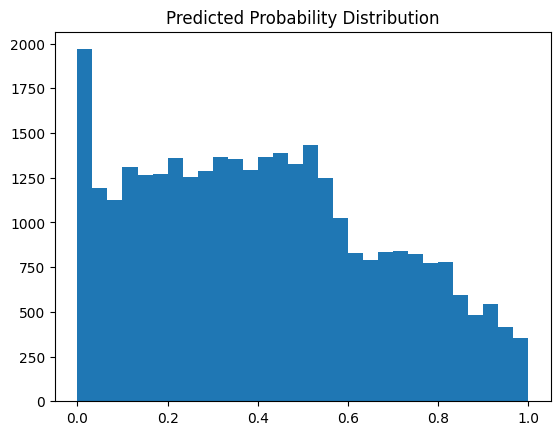

In [14]:
probs = rf.predict_proba(X_test)[:, 1] # prob of high severity
import matplotlib.pyplot as plt

plt.hist(probs, bins=30) # distribution of predicted risk
plt.title("Predicted Probability Distribution")
plt.show()

In [16]:
def dispatch_level(prob, visibility, wind_speed): # dispatch rule engine - gives us operational instructions to act on based on the data
    if prob > 0.75 and visibility < 2:
        return "Level 3 - Full Emergency Response"
    elif prob > 0.75:
        return "Level 2 - Priority Dispatch"
    elif prob > 0.5:
        return "Level 1 - Elevated Monitoring"
    else:
        return "Standard Response"

In [17]:
def human_review(prob): # if the prob is near threshold, we dont want to rely on ml model so we flag it for human review, not blindly trusting
    return 0.45 < prob < 0.55

In [18]:
importances = rf.feature_importances_ # measured how much each feature contributed to reduing impurity in trees (temp, humidity, pressure)

for feature, importance in zip(features, importances):
    print(feature, importance)

    # our model tells us that environment factors are predictive and can contribute to these type of interpretations

Temperature(F) 0.25768406467158866
Humidity(%) 0.2478438942382872
Pressure(in) 0.2713749040044937
Visibility(mi) 0.037456107750843
Wind_Speed(mph) 0.1606026711256374
Distance(mi) 0.02503835820915003


In [19]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, probs) # model’s ability to rank high-severity cases above low-severity cases across all possible thresholds
print("ROC-AUC:", roc_auc) # ours is moderately predictive

ROC-AUC: 0.6667771560124315


In [20]:
import numpy as np

threshold = 0.35 # now we do some threshold tuning to give up a little bit of precision for recall
y_pred_custom = (probs >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

# did this bc, in high-stakes systems, missing severe accidents is worse than false alarms, so adjusted the decision threshold to reflect risk tolerance

              precision    recall  f1-score   support

           0       0.72      0.53      0.61     18948
           1       0.50      0.70      0.59     12950

    accuracy                           0.60     31898
   macro avg       0.61      0.61      0.60     31898
weighted avg       0.63      0.60      0.60     31898



## Responsible AI Considerations

- High-severity recall prioritized due to safety-critical context.
- Low-confidence predictions escalated to human operators.
- Environmental-only features reduce demographic bias risk.
- Model performance should be monitored for distribution shift (e.g., seasonal changes).
- Continuous retraining recommended.